<div style="
    display: flex;
    justify-content: center;
    align-items: center;
    flex-direction: column;
    max-width: 99%;
    box-sizing: border-box;
    border: 1px solid rgba(208, 49, 30, 0.25);
    border-radius: 20px 20px 5px 5px;
    padding: 30px 40px;
    margin: 20px 0 30px 0;
    text-align: center;
    background: linear-gradient(135deg, rgba(208, 49, 30, 0.08), rgba(208, 49, 30, 0.02));
    box-shadow: 0 2px 15px rgba(208, 49, 30, 0.08);
    backdrop-filter: blur(3px);
    font-family: 'Palatino', serif;
">
    <div style="
        display: inline-block;
        background: #FF5722;
        color: #ffffff;
        padding: 4px 5px;
        border-radius: 30px;
        font-size: 11px;
        font-weight: 600;
        letter-spacing: 5px;
        box-shadow: 0 2px 8px rgba(208, 49, 30, 0.3);
        margin-bottom: 15px;
    ">
        SCHOOL 21
    </div>
    <h1 style="
        margin: 0;
        color: #F7D87F;
        font-size: clamp(24px, 4vw, 32px);
        font-weight: 700;
        letter-spacing: 1px;
        word-wrap: break-word;
    ">
        ML3_Validation
    </h1>
    <div style="
        display: flex;
        justify-content: center;
        gap: 10px;
        margin-top: 10px;
        flex-wrap: wrap;
    ">
        <span style="width: 30px; height: 2px; background: #D0311E; opacity: 0.25; flex-shrink: 0;"></span>
        <span style="width: 60px; height: 2px; background: #D0311E; opacity: 0.5; flex-shrink: 0;"></span>
        <span style="width: 30px; height: 2px; background: #D0311E; opacity: 0.25; flex-shrink: 0;"></span>
    </div>
    <p style="
        margin: 8px 0 0 0;
        color: #F8EBAB;
        font-size: 14px;
        font-style: italic;
        letter-spacing: 1px;
        word-wrap: break-word;
    ">
        joanegla
    </p>
</div>

<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 00
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        Import
    </h2>
</div>

In [30]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split, StratifiedKFold, TimeSeriesSplit, KFold
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.linear_model import LinearRegression, SGDRegressor 
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as rmse, mean_squared_error as mse, r2_score as r2
from utils import display_table

In [31]:
def remove_punctuation(df):
    """
    Функция для удаления некоторой пунктуации из признаков
    """
    df['features'] = df['features'].astype(str).str.translate(str.maketrans('', '', '[]"\' '))
    return df

In [32]:
def get_features(df):
    """
    Функция для выделения отдельных характеристик из столбца features
    """
    features = []
    for i, row in df.iterrows():
        if isinstance(row['features'], str):
            slice = row['features'].split(',')
            for i in slice:
                if i != '': features.append(i.strip())
        else:
            if row['features'] != '' and row['features'] is not None:
                features.append(row['features'])
    return features

In [33]:
def feature_engineering(df, features):
    """
    Функция выделяет 20 самых популярных признаков и добавляет их в датафрейм
    """
    top = Counter(features).most_common(20)
    top20 = [item for item, c in top]
    for feature in top20:
        df[feature] = df['features'].apply(lambda x: 1 if feature in x else 0)

    feature_list = top20 + ['bathrooms', 'bedrooms']
    return feature_list

<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 01
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        ATQ
    </h2>
</div>

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Leave-one-out
    </h2>
</div>

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Grid Search & Bayesian optimization
    </h2>
</div>

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Feature selection methods
    </h2>
</div>

<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 02
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        Introduction
    </h2>
</div>

In [34]:
train_data = pd.read_json('data/train.json')
train = train_data[(train_data['price'] < train_data['price'].quantile(0.99)) & (train_data['price'] > train_data['price'].quantile(0.01))].copy()

In [35]:
def processing_data(train_data):
    train_data = remove_punctuation(train_data)

    features_train = get_features(train_data)

    print(f'Всего значений train: {len(features_train)}')
    print(f'Уникальных значений train: {len(set(features_train))}')

    feature_list = feature_engineering(train_data, features_train)

    return train_data,  feature_list

train, feature_list = processing_data(train_data)

Всего значений train: 267906
Уникальных значений train: 1546


In [36]:
# pd.to_datetime(train['created'])

In [37]:
feature_list

['Elevator',
 'CatsAllowed',
 'HardwoodFloors',
 'DogsAllowed',
 'Doorman',
 'Dishwasher',
 'NoFee',
 'LaundryinBuilding',
 'FitnessCenter',
 'Pre-War',
 'LaundryinUnit',
 'RoofDeck',
 'OutdoorSpace',
 'DiningRoom',
 'HighSpeedInternet',
 'Balcony',
 'SwimmingPool',
 'LaundryInBuilding',
 'NewConstruction',
 'Terrace',
 'bathrooms',
 'bedrooms']

In [38]:
X = train[feature_list + ['bathrooms','bedrooms']]
y = train['price']
y_stratified = pd.qcut(y, q=10, labels=False)

<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 03
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        Data split
    </h2>
</div>

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Train-Test Split
    </h2>
</div>

In [39]:
def own_train_test_split(
    array,
    test_size:          float | None,
    train_size:         float | None = None,
    random_state:       int | None = None
):
    """
    Метод разделяет массив на две выборки: тренировочную и тестовую
    """
    n_samples = len(array)

    if n_samples == 0:
        raise ValueError("Empty array")

    if test_size is not None and not 0 < test_size < 1:
        raise ValueError("test_size must be between 0 and 1, got {test_size}")
    if train_size is not None and not 0 < train_size < 1:
        raise ValueError("train_size must be between 0 and 1, got {train_size}")

    if random_state:
        np.random.seed(random_state)

    idx = np.arange(n_samples)

    np.random.shuffle(idx)

    if test_size is not None:       percentile = test_size
    elif train_size is not None:    percentile = 1 - train_size
    else: percentile = 0.25

    split_point = int(n_samples * percentile)
    
    train_idx = idx[split_point:]
    test_idx = idx[:split_point]

    if hasattr(array, 'iloc'):          # DataFrames, Series
        train = array.iloc[train_idx]
        test = array.iloc[test_idx]  
    else:                               # Arrays, Lists, Scipy.sparce
        train = array[train_idx]
        test = array[test_idx]

    return train, test

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Train-Test-Valid Split
    </h2>
</div>

In [40]:
def own_train_test_val_split(
    array,
    test_size:          float | None,
    val_size:           float | None,
    train_size:         float | None = None,
    random_state:       int | None = None
):
    """
    Метод разделяет массив на две выборки: тренировочную и тестовую
    """
    train, test = own_train_test_split(array=array, test_size=test_size, train_size=train_size, random_state=random_state)
    train, val = own_train_test_split(array=train, test_size=val_size, train_size=train_size, random_state=random_state)

    return train, test, val

In [41]:
train_split, test_split, val_split = own_train_test_val_split(train, test_size=0.25, val_size=0.25)

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Train-Test by date Split
    </h2>
</div>

In [42]:
def own_train_test_split(
    array,
    date_time:          str | None = None,
    date_col = None
):
    """
    Метод разделяет массив по дате: на тренировочную и тестовую
    """
    array = array.copy()
    if date_time is not None:
        try:
            date_time = np.datetime64(date_time)
        except:
            raise ValueError('invalid value')
    
    n_samples = len(array)

    if n_samples == 0:
        raise ValueError("Empty array")

    if date_time is not None and not isinstance(date_time, np.datetime64):
        raise ValueError("date_time must be datetime, got {}")
    
    idx = np.arange(n_samples)
    
    
    if date_time is None:
        split_point = int(n_samples * 0.8)
    
        train_idx = idx[:split_point]
        test_idx = idx[split_point:]

        if hasattr(array, 'iloc'):          # DataFrames, Series
            train = array.iloc[train_idx]
            test = array.iloc[test_idx]  
        else:                               # Arrays, Lists, Scipy.sparce
            train = array[train_idx]
            test = array[test_idx]
    else:
        if isinstance(array, pd.Series):
            min_date = array.index.min()
            max_date = array.index.max()
            if date_time < min_date or date_time > max_date:
                raise ValueError(f"date_time must be between {min_date} and {max_date}")
            train = array[array.index <= date_time]
            test = array[array.index > date_time]

        if isinstance(array, pd.DataFrame):
            if date_col is None:
                try:
                    min_date = array.index.min()
                    max_date = array.index.max()
                    if date_time < min_date or date_time > max_date:
                        raise ValueError(f"date_time must be between {min_date} and {max_date}")
                    train = array[array.index <= date_time]
                    test = array[array.index > date_time]
                except:
                    raise ('index error')
            else:
                if date_col not in array.columns:
                    raise ValueError(f"Column {date_col} not found")
                array[date_col] = pd.to_datetime(array[date_col])
                if date_time < (array[date_col]).min() or date_time > array[date_col].max():
                    raise ValueError("date_time must be between min and max date in array, got {}")

                train = array[array[date_col] <= date_time]
                test = array[array[date_col] > date_time]

    return train, test

In [43]:
train_split, test_split = own_train_test_split(train, '2016-04-26', 'created')

In [44]:
train_split['created'].max()

Timestamp('2016-04-25 22:36:11')

In [45]:
test_split['created'].min()

Timestamp('2016-04-26 00:47:10')

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Train-Test-Vaild by date Split
    </h2>
</div>

In [46]:
def own_train_test_val_split(
    array,
    test_time:  str | None = None,
    val_time:   str | None = None,
    date_col =  None
    ):
    """
    Метод разделяет массив на две выборки: тренировочную и тестовую
    """
    train, test = own_train_test_split(array, test_time, date_col)
    train, val = own_train_test_split(train, val_time, date_col)

    return train, test, val

In [47]:
train_split, test_split, val_split = own_train_test_val_split(train,'2016-04-26', '2016-04-20', 'created')

<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 04
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        K-Fold
    </h2>
</div>

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Standart K-Fold
    </h2>
</div>

In [48]:
class O_KFold:
    def __init__(
            self,
            n_splits        : int  = 5,
            shuffle         : bool = None,
            random_state    : int  = None
        ):
        self.n_splits        = n_splits
        self.shuffle         = shuffle
        self.random_state    = random_state

    def split(self, X, y=None):
        length = len(X)
        if length == 0:
            raise ValueError('array must be not empty')
        
        idx = np.arange(length)

        if self.shuffle:
            if self.random_state:   np.random.seed(self.random_state)
            np.random.shuffle(idx)

        fold_size = length // self.n_splits
        remainder = length % self.n_splits
        start = 0

        folds = []

        for i in range(self.n_splits):
            cur_fold_size = fold_size + (1 if i < remainder else 0)

            folds.append(idx[start:(start + cur_fold_size)])

            start += cur_fold_size

        for i in range(self.n_splits):
            test_idx = folds[i]
            train_idx = np.concatenate([folds[j] for j in range(self.n_splits) if j != i])

            yield train_idx, test_idx

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Grouped K-Fold
    </h2>
</div>

In [49]:
class O_GroupKFold:
    def __init__(
            self,
            n_splits        : int  = 5,
            shuffle         : bool = False,
            random_state    : int  = None
        ):
        self.n_splits     = n_splits
        self.shuffle      = shuffle
        self.random_state = random_state

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("groups cannot be None")
        
        groups = np.array(groups)
        length = len(X)
        
        if length == 0:
            raise ValueError('array must be not empty')
        
        unique_groups = np.unique(groups)
        
        if self.n_splits > len(unique_groups):
            raise ValueError(f"n_splits={self.n_splits} > number of groups={len(unique_groups)}")
        
        if self.shuffle:
            if self.random_state is not None:
                np.random.seed(self.random_state)
            np.random.shuffle(unique_groups)
        
        group_folds = np.array_split(unique_groups, self.n_splits)
        
        for fold_groups in group_folds:
            test_idx = np.where(np.isin(groups, fold_groups))[0]
            train_idx = np.where(~np.isin(groups, fold_groups))[0]
            
            yield train_idx, test_idx

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Stratified K-Fold
    </h2>
</div>

In [50]:
class O_StratifiedKFold:
    def __init__(
            self,
            n_splits        : int   = 5,
            shuffle         : bool  = False,
            random_state    : int   = None
        ):
        self.n_splits       = n_splits
        self.shuffle        = shuffle
        self.random_state   = random_state

    def split(self, X, y):
        length = len(X)
        if length == 0:
            raise ValueError('array must be not empty')
        if self.n_splits > length:
            raise ValueError(f'n_splits={self.n_splits} > samples={length}')
        
        y = np.array(y)
        idx = np.arange(length)
        
        # Перемешиваем (если нужно)
        if self.shuffle:
            if self.random_state is not None:
                np.random.seed(self.random_state)
            np.random.shuffle(idx)
            y = y[idx]
        
        # Группируем индексы по классам
        unique_classes = np.unique(y)
        class_indices = {cls: [] for cls in unique_classes}
        for i, label in zip(idx, y):
            class_indices[label].append(i)
        
        # Создаем фолды
        folds = [[] for _ in range(self.n_splits)]
        
        # Распределяем каждый класс равномерно по фолдам
        for cls in unique_classes:
            cls_idxs = class_indices[cls]
            # Перемешиваем внутри класса
            if self.shuffle:
                np.random.shuffle(cls_idxs)
            
            # Разбиваем на n_splits частей
            splits = np.array_split(cls_idxs, self.n_splits)
            
            # Раскладываем по фолдам
            for fold_idx, split in enumerate(splits):
                folds[fold_idx].extend(split)
        
        # Возвращаем индексы
        for fold_idx in range(self.n_splits):
            test_idx = np.array(folds[fold_idx])
            train_idx = np.array([i for i in idx if i not in test_idx])
            
            yield train_idx, test_idx
    
    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Time series split
    </h2>
</div>

In [51]:
class O_TimeSeriesSplit:
    def __init__(
            self,
            n_splits        : int = 5,
            max_train_size  : int = None,
            test_size       : int = 1,
            gap             : int = 0
        ):
        self.n_splits       = n_splits
        self.max_train_size = max_train_size
        self.test_size      = test_size
        self.gap            = gap

    def split(self, X):
        length = len(X)
        if length == 0:
            raise ValueError('array must be not empty')
        
        idx = np.arange(length)

        total_el = self.n_splits * self.test_size
        gap_el = self.gap * (self.n_splits - 1)

        if length < total_el + gap_el:
            raise ValueError('the number of elements is not enough to split')

        t_start = length - total_el - self.gap

        for i in range(self.n_splits):
            test_start = t_start + i * (self.test_size + self.gap)
            train_end = test_start - self.gap

            train_idx = idx[:train_end]
            
            if self.max_train_size is not None and len(train_idx) > self.max_train_size:
                train_idx = train_idx[-self.max_train_size:]

            test_idx = idx[test_start:test_start + self.test_size]
            
            yield train_idx, test_idx

<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 05
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        Cross-validation
    </h2>
</div>

In [52]:
my_kf = O_KFold(n_splits=5, shuffle=True, random_state=42)
my_gkf = O_GroupKFold(n_splits=5, shuffle=True, random_state=42)
my_skf = O_StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
my_ts = O_TimeSeriesSplit(n_splits=5, test_size=1)

from sklearn.model_selection import KFold, GroupKFold, StratifiedKFold, TimeSeriesSplit

sk_kf = KFold(n_splits=5, shuffle=True, random_state=42)
sk_gkf = GroupKFold(n_splits=5, shuffle=True, random_state=42)
sk_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sk_ts = TimeSeriesSplit(n_splits=5, test_size=1)

In [53]:
def compare_splits(my_splitter, sk_splitter, X, y, groups=None):
    print(f"Сравнение: {my_splitter.__class__.__name__}")

    if groups is not None:
        my_indices = list(my_splitter.split(X, y, groups=groups))
    else:
        my_indices = list(my_splitter.split(X))
    
    if groups is not None:
        sk_indices = list(sk_splitter.split(X, y, groups=groups))
    elif 'y' in sk_splitter.split.__code__.co_varnames:
        sk_indices = list(sk_splitter.split(X, y))
    else:
        sk_indices = list(sk_splitter.split(X))
    
    for i, ((my_train, my_test), (sk_train, sk_test)) in enumerate(zip(my_indices, sk_indices)):
        assert len(my_train) == len(sk_train), f"Fold {i}: train sizes differ"
        assert len(my_test) == len(sk_test), f"Fold {i}: test sizes differ"
        
        if not my_splitter.shuffle:
            assert np.array_equal(my_train, sk_train), f"Fold {i}: train indices differ"
            assert np.array_equal(my_test, sk_test), f"Fold {i}: test indices differ"
        
        print(f"  Fold {i}: train={len(my_train)}, test={len(my_test)}")
    
    print("Фолды совпадают\n")

In [54]:
def compare_splits(my_splitter, sk_splitter, X, y=None, groups=None):
    print(f"Сравнение: {my_splitter.__class__.__name__}")
    
    # Моя реализация
    try:
        if groups is not None:
            my_indices = list(my_splitter.split(X, y, groups=groups))
        else:
            my_indices = list(my_splitter.split(X, y))
    except TypeError:
        try:
            my_indices = list(my_splitter.split(X, groups=groups))
        except TypeError:
            my_indices = list(my_splitter.split(X))
    
    # sklearn
    try:
        if groups is not None:
            sk_indices = list(sk_splitter.split(X, y, groups=groups))
        else:
            sk_indices = list(sk_splitter.split(X, y))
    except TypeError:
        try:
            sk_indices = list(sk_splitter.split(X, groups=groups))
        except TypeError:
            sk_indices = list(sk_splitter.split(X))
    
    # Сравниваем
    for i, ((my_train, my_test), (sk_train, sk_test)) in enumerate(zip(my_indices, sk_indices)):
        assert len(my_train) == len(sk_train), f"Fold {i}: train sizes differ"
        assert len(my_test) == len(sk_test), f"Fold {i}: test sizes differ"
        
        print(f"  Fold {i}: train={len(my_train)}, test={len(my_test)}")
    
    print("Фолды совпадают\n")

In [55]:
def evaluate_cv(X, y, cv_method, model, scoring, groups=None):
    """
    Оценивает модель с помощью перекрестной проверки
    """
    scores = []
    if groups: split = cv_method.split(X, y, groups=groups)
    else: split = cv_method.split(X, y)
    for train_idx, test_idx in split:
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        scores.append(scoring(y_test, y_pred))
    
    return np.array(scores)

In [56]:
compare_splits(my_kf, sk_kf, X, y)

groups = train['bedrooms']
compare_splits(my_gkf, sk_gkf, X, y, groups=groups)

compare_splits(my_ts, sk_ts, X, y)

Сравнение: O_KFold
  Fold 0: train=39481, test=9871
  Fold 1: train=39481, test=9871
  Fold 2: train=39482, test=9870
  Fold 3: train=39482, test=9870
  Fold 4: train=39482, test=9870
Фолды совпадают

Сравнение: O_GroupKFold
  Fold 0: train=33598, test=15754
  Fold 1: train=39630, test=9722
  Fold 2: train=34727, test=14625
  Fold 3: train=40147, test=9205
  Fold 4: train=49306, test=46
Фолды совпадают

Сравнение: O_TimeSeriesSplit
  Fold 0: train=49347, test=1
  Fold 1: train=49348, test=1
  Fold 2: train=49349, test=1
  Fold 3: train=49350, test=1
  Fold 4: train=49351, test=1
Фолды совпадают



In [57]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

model = Ridge(alpha=1.0)

my_skf = O_StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
my_scores = evaluate_cv(X, y_stratified, my_skf, model, mean_absolute_error)

sk_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sk_scores = evaluate_cv(X, y_stratified, sk_skf, model, mean_absolute_error)

print(f"Моя реализация: {my_scores.mean():.2f} ± {my_scores.std():.2f}")
print(f"Sklearn: {sk_scores.mean():.2f} ± {sk_scores.std():.2f}")

Моя реализация: 1.59 ± 0.00
Sklearn: 1.59 ± 0.01


In [58]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

model = Ridge(alpha=1.0)

methods = {
    'KFold': KFold(n_splits=5, shuffle=True, random_state=42),
    'StratifiedKFold': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    'TimeSeriesSplit': TimeSeriesSplit(n_splits=5),
}

for name, cv in methods.items():
    scores = evaluate_cv(X, y, cv, model, mean_absolute_error)
    print(f"{name}:")
    print(f"  Средняя MAE: {scores.mean():.2f} ± {scores.std():.2f}")

KFold:
  Средняя MAE: 1161.56 ± 107.83
StratifiedKFold:
  Средняя MAE: 1164.30 ± 160.25
TimeSeriesSplit:
  Средняя MAE: 1303.99 ± 214.85


/home/jarvis/pandasvenv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 06
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        Feature Selection
    </h2>
</div>

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)
lasso.fit(X_scaled, y)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lasso.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("Топ-10 признаков по Lasso:")
print(feature_importance.head(10))

n_selected = np.sum(lasso.coef_ != 0)
print(f"\nLasso оставил {n_selected} признаков из {len(X.columns)}")

top10_lasso = feature_importance.head(10)['feature'].tolist()
X_lasso = X[top10_lasso]

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

model = Ridge(alpha=1.0)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores_all = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
print(f"Все признаки: {-scores_all.mean():.2f} ± {scores_all.std():.2f}")

scores_lasso = cross_val_score(model, X_lasso, y, cv=kf, scoring='neg_mean_absolute_error')
print(f"Топ-10 Lasso: {-scores_lasso.mean():.2f} ± {scores_lasso.std():.2f}")

Топ-10 признаков по Lasso:
              feature  coefficient
20          bathrooms  1351.885993
4             Doorman   767.121664
21           bedrooms   493.710686
7   LaundryinBuilding  -290.729225
0            Elevator   266.046400
22          bathrooms  -261.428145
3         DogsAllowed   259.551139
10      LaundryinUnit   218.149498
8       FitnessCenter  -195.201955
6               NoFee  -181.499836

Lasso оставил 24 признаков из 24
Все признаки: 1161.56 ± 107.83
Топ-10 Lasso: 1148.84 ± 112.36


In [ ]:
correlations = X.corrwith(y).abs().sort_values(ascending=False)

print("Топ-10 признаков по корреляции с ценой:")
print(correlations.head(10))

top10_corr = correlations.head(10).index.tolist()
X_corr = X[top10_corr]

scores_corr = cross_val_score(model, X_corr, y, cv=kf, scoring='neg_mean_absolute_error')
print(f"Топ-10 по корреляции: {-scores_corr.mean():.2f} ± {scores_corr.std():.2f}")

Топ-10 признаков по корреляции с ценой:
bathrooms        0.069661
bathrooms        0.069661
bedrooms         0.051788
bedrooms         0.051788
Doorman          0.033875
Elevator         0.023479
LaundryinUnit    0.022481
DiningRoom       0.021228
FitnessCenter    0.015368
Terrace          0.014562
dtype: float64
Топ-10 по корреляции: 1113.69 ± 126.71


In [ ]:
from sklearn.inspection import permutation_importance

model.fit(X, y)

perm_importance = permutation_importance(
    model, X, y, 
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_absolute_error'
)

feature_importance_perm = pd.DataFrame({
    'feature': X.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print("Топ-10 признаков по Permutation Importance:")
print(feature_importance_perm.head(10))

top10_perm = feature_importance_perm.head(10)['feature'].tolist()
X_perm = X[top10_perm]

scores_perm = cross_val_score(model, X_perm, y, cv=kf, scoring='neg_mean_absolute_error')
print(f"Топ-10 по Permutation: {-scores_perm.mean():.2f} ± {scores_perm.std():.2f}")

Топ-10 признаков по Permutation Importance:
              feature  importance       std
22          bathrooms  363.151805  2.763270
20          bathrooms  363.151805  2.763270
4             Doorman  273.382358  2.055873
21           bedrooms  210.546287  1.234517
23           bedrooms  210.546287  1.234517
7   LaundryinBuilding   41.467942  0.801163
10      LaundryinUnit   36.854536  0.607997
0            Elevator   29.259545  1.076554
8       FitnessCenter   23.457200  0.745138
17  LaundryInBuilding   17.417731  0.697990
Топ-10 по Permutation: 1133.32 ± 116.70


Background dataset has 49352 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=49352 when initializing the masker.
/tmp/ipykernel_1203925/4260832238.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, feature_names=X.columns, plot_type="bar")


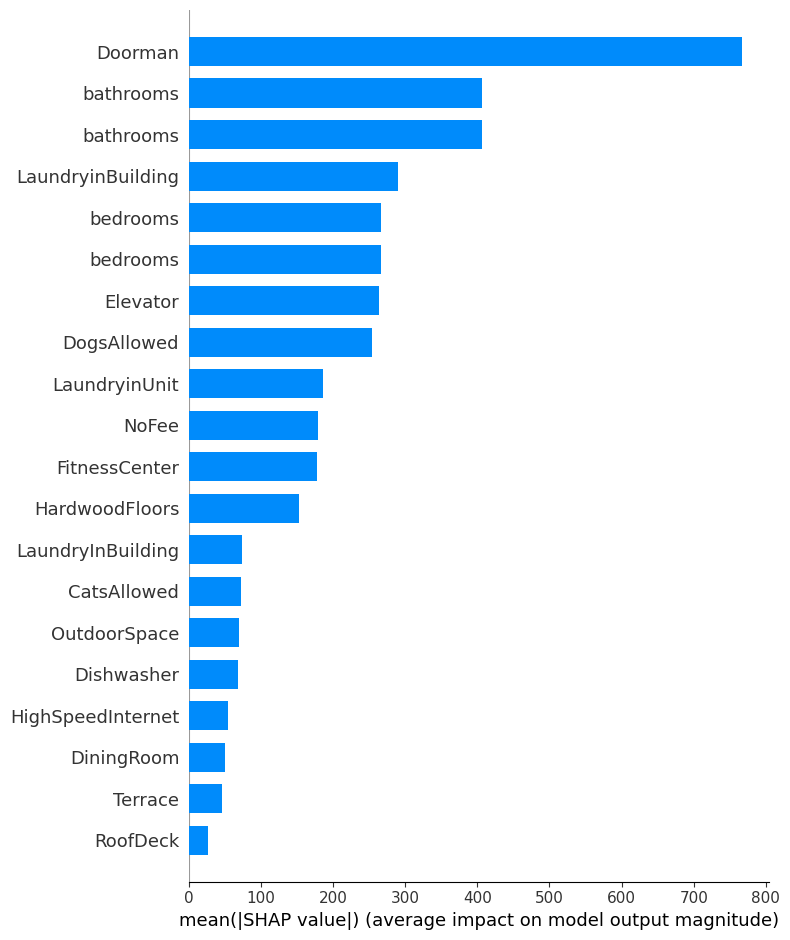

/tmp/ipykernel_1203925/4260832238.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, feature_names=X.columns)


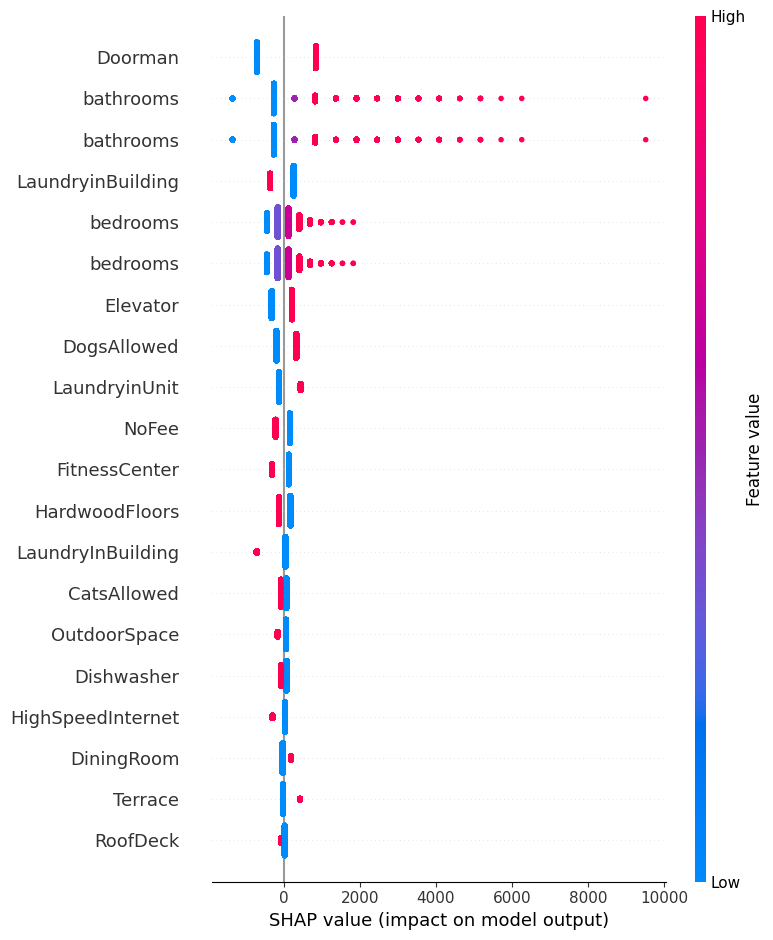

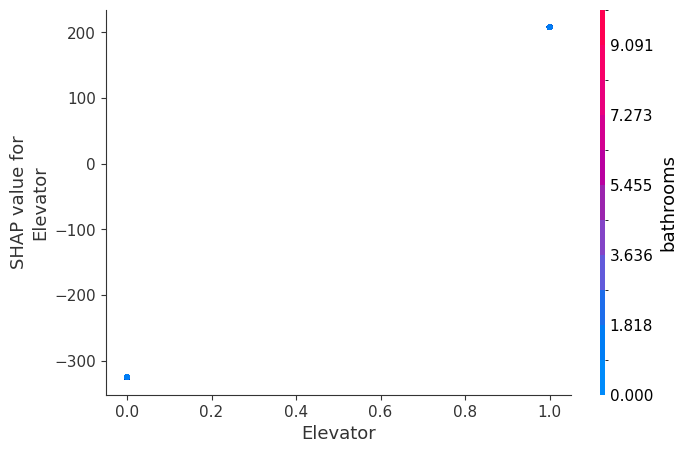

Топ-10 признаков по SHAP:
              feature  importance
4             Doorman  766.497487
22          bathrooms  407.072138
20          bathrooms  407.072138
7   LaundryinBuilding  290.041202
23           bedrooms  266.500048
21           bedrooms  266.500048
0            Elevator  263.438317
3         DogsAllowed  254.295125
10      LaundryinUnit  186.073242
6               NoFee  179.303942
Топ-10 по SHAP: 1131.69 ± 118.89


In [ ]:
import shap

model = Ridge(alpha=1.0)
model.fit(X, y)

explainer = shap.LinearExplainer(model, X)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X, feature_names=X.columns, plot_type="bar")

shap.summary_plot(shap_values, X, feature_names=X.columns)

shap.dependence_plot(0, shap_values, X, feature_names=X.columns)

shap_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

print("Топ-10 признаков по SHAP:")
print(shap_importance.head(10))

top10_shap = shap_importance.head(10)['feature'].tolist()
X_shap = X[top10_shap]

scores_shap = cross_val_score(model, X_shap, y, cv=kf, scoring='neg_mean_absolute_error')
print(f"Топ-10 по SHAP: {-scores_shap.mean():.2f} ± {scores_shap.std():.2f}")

<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 07
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        Hyperparameter optimization
    </h2>
</div>

In [ ]:
import itertools
from sklearn.metrics import get_scorer

class GridSearchCV:
    def __init__(
        self,
        estimator,
        param_grid          : dict,
        scoring             : str       = None,
        cv                  : int       = None,
        n_jobs              : int       = 1,
        verbose             : int       = 0,
        return_train_score  : bool      = False,
        refit               : bool|str  = True,
        error_score         : int|str   = np.nan,
        pre_dispatch        : int|str   = '2*n_jobs'
    ):
        self.estimator          = estimator
        self.param_grid         = param_grid
        self.scoring            = scoring
        self.cv                 = cv
        self.n_jobs             = n_jobs
        self.verbose            = verbose
        self.return_train_score = return_train_score
        self.refit              = refit
        self.error_score        =  error_score
        self.pre_dispatch       =  pre_dispatch

        self.cv_results_        = {}
        self.best_estimator_    = None
        self.best_score_        = 0
        self.best_params_       = None
        self.best_index_        = None
        self.scorer_            = None
        self.n_splits_          = None

    def fit(self, X, y):
        if self.scoring is None:
            self.scorer_ = self.estimator.score
        elif isinstance(self.scoring, str):
            self.scorer_ = get_scorer(self.scoring)
        else:
            self.scorer_ = self.scoring

        param_product = itertools.product(*self.param_grid.values())
        param_names = self.param_grid.keys()

        folds = KFold(self.cv, random_state=21).split(X, y)

        for combo in param_product:
            param = dict(zip(param_names, combo))

            if isinstance(self.estimator, type):
                model = self.estimator(**param)
            else:
                model = self.estimator.__class__(**param)

            fold_score = []

            for (train_idx, test_idx) in folds:
                model.fit(X.iloc[train_idx], y.iloc[train_idx])
                y_pred = model.predict(X.iloc[test_idx])
                score = self.scorer_(y.iloc[test_idx], y_pred)
                if score < self.best_score_: self.best_score_ = score
                fold_score.append(score)

            std = np.std(fold_score)
            mean = np.mean(fold_score)

            


    def predict(self, X):
        pass

    def predict_proba(self, X):
        pass

    def transform(self, X):
        pass

    def inverse_transform(self, X):
        pass

    def score(self, X, y):
        pass

In [64]:
x = {'alpha': [0.1, 1.0], 'l1_ratio': [0.5, 0.7]}
x

{'alpha': [0.1, 1.0], 'l1_ratio': [0.5, 0.7]}

In [65]:
len(x.values())

2

In [66]:
import itertools
for i in itertools.product(*x.values()):
    print(dict(zip(x.keys(),i)))

{'alpha': 0.1, 'l1_ratio': 0.5}
{'alpha': 0.1, 'l1_ratio': 0.7}
{'alpha': 1.0, 'l1_ratio': 0.5}
{'alpha': 1.0, 'l1_ratio': 0.7}


In [67]:
from sklearn.linear_model import ElasticNet

ElasticNet({'alpha': 0.1, 'l1_ratio': 0.5})

,alpha,"{'alpha': 0.1, 'l1_ratio': 0.5}"
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [76]:
list(KFold().split(train))

[(array([ 9871,  9872,  9873, ..., 49349, 49350, 49351], shape=(39481,)),
  array([   0,    1,    2, ..., 9868, 9869, 9870], shape=(9871,))),
 (array([    0,     1,     2, ..., 49349, 49350, 49351], shape=(39481,)),
  array([ 9871,  9872,  9873, ..., 19739, 19740, 19741], shape=(9871,))),
 (array([    0,     1,     2, ..., 49349, 49350, 49351], shape=(39482,)),
  array([19742, 19743, 19744, ..., 29609, 29610, 29611], shape=(9870,))),
 (array([    0,     1,     2, ..., 49349, 49350, 49351], shape=(39482,)),
  array([29612, 29613, 29614, ..., 39479, 39480, 39481], shape=(9870,))),
 (array([    0,     1,     2, ..., 39479, 39480, 39481], shape=(39482,)),
  array([39482, 39483, 39484, ..., 49349, 49350, 49351], shape=(9870,)))]